In [1]:
from typing import Optional
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.nn import ReLU

from pfhedge.instruments import BrownianStock
from pfhedge.instruments import EuropeanOption
from pfhedge.instruments import FixedStock
from pfhedge.nn import BlackScholes
from pfhedge.nn import BSEuropeanOption
from pfhedge.nn import EntropicRiskMeasure
from pfhedge.nn import ExpectedShortfall
from pfhedge.nn import Hedger
from pfhedge.nn import MultiLayerPerceptron

In [3]:
def load_quotes(file_path: str) -> torch.Tensor:
    quotes = pd.read_csv(file_path)
    close = torch.tensor(quotes["Close"].values, dtype=torch.float)
    return close


def generate_log_normal_brownian(
    sigma: float, mu: float, dt: float, n_steps: int, seed: Optional[int] = None
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Generate a log-normal Brownian motion time series.

    Args:
        sigma (float): Volatility parameter.
        dt (float): Time step size.
        n_steps (int): Number of time steps.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        Tuple[torch.Tensor, torch.Tensor]: Tuple containing the log series and the
            exponential series.
    """
    if seed is not None:
        torch.manual_seed(seed)
    # Generate Brownian increments
    increments = torch.randn(n_steps - 1) * np.sqrt(sigma**2 * dt) + mu * dt
    # Convert to log-normal Brownian motion
    log_series = torch.cat([torch.zeros(1), torch.cumsum(increments, dim=0)])
    series = torch.exp(log_series)
    return series


def get_derivative(
    sigma: float, mu: float, dt: float, strike: float, maturity: float, cost: float = 0.0
) -> EuropeanOption:
    stock = BrownianStock(cost=cost, sigma=sigma, mu=mu, dt=dt)
    derivative = EuropeanOption(stock, strike=strike, maturity=maturity)
    return derivative


def loss_hedger(loss, derivative, features, n_epochs, n_paths, init_spot) -> Hedger:
    # Create MLP hedger
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    # Fit the hedger
    history = hedger.fit(derivative, n_epochs=n_epochs, n_paths=n_paths, init_state=(init_spot,))
    return hedger, history


def blackscholes_hedger(derivative) -> Hedger:
    # Create instruments
    model = BlackScholes(derivative)
    hedger_bs = Hedger(model, model.inputs())
    return hedger_bs


def fit(init_spot, strike, cost, n_epochs = 200, n_paths = 10000):
    torch.manual_seed(1234)
    # Set up the hedgers
    loss_functions = {
        "Entropic Risk Measure (a=1)": EntropicRiskMeasure(a=1),
        "Entropic Risk Measure (a=0.1)": EntropicRiskMeasure(a=0.1),
        "Expected Shortfall (95%)": ExpectedShortfall(0.05),
        "Expected Shortfall (50%)": ExpectedShortfall(0.5),
    }
    hedgers = {}
    derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
    hedger = blackscholes_hedger(derivative)
    hedgers["Black-Scholes"] = (hedger, derivative, [])
    for name, loss in loss_functions.items():
        derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
        hedger, history = loss_hedger(loss, derivative, features, n_epochs, n_paths, init_spot)
        hedgers[name] = (hedger, derivative, history)

    # PnL statistics
    pnls = {}
    histories = {}
    for name, (hedger, derivative, history) in hedgers.items():
        derivative.simulate(n_paths=10000, init_state=(init_spot,))
        pnls[name] = hedger.compute_pl(derivative)
        histories[name] = history
    print("PnL Statistics:")
    for name, pnl in pnls.items():
        print(f"{name}: {pnl.mean():.6f} ({pnl.std():.6f})")

    # Calculate global min and max for uniform binning
    all_pnls = torch.cat([pnl for pnl in pnls.values()]).detach().numpy()
    bin_edges = np.linspace(all_pnls.min(), all_pnls.max(), 101)

    # Plot PnL distributions and fitting history in subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # Plot PnL distributions
    for name, pnl in pnls.items():
        ax1.hist(pnl.detach().numpy(), bins=bin_edges, label=name, histtype="step", alpha=0.5)
    ax1.set_title("PnL Distribution")
    ax1.set_xlabel("PnL")
    ax1.set_ylabel("Frequency")
    ax1.legend()
    ax1.grid(True)
    # Plot fitting history
    for name, history in histories.items():
        ax2.plot(history, label=name)
    ax2.set_title("Training History")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.set_yscale('log')  # Add log scale
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()
    return hedgers

In [4]:
torch.manual_seed(1234)

# Set up the instruments
dt = 1 / 250
vol = 0.4
mu = 0.0
init_spot = 3
cost = 0.0

# Set up the derivative
strike = 3
term = 30
maturity = term * dt
features = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]

# series = generate_log_normal_brownian(sigma=vol, mu=mu, dt=dt, n_steps=term * 3 + 10)
series = load_quotes("000905.csv")
fixed_stock = FixedStock(spots=list(series), cost=cost, dt=dt)
sigma = fixed_stock.volatility  # use realized volatility in simulation
print(f"Realized Volatility: {sigma:.6f}")

Realized Volatility: 0.210123


Loss=0.0588: 100%|██████████| 1/1 [00:00<00:00, 13.63it/s]


PnL Statistics:
Black-Scholes: -0.029112 (0.004596)
Entropic Risk Measure (a=1): -0.029118 (0.034968)
Entropic Risk Measure (a=0.1): -0.028837 (0.046726)
Expected Shortfall (95%): -0.029236 (0.040224)
Expected Shortfall (50%): -0.028942 (0.042427)


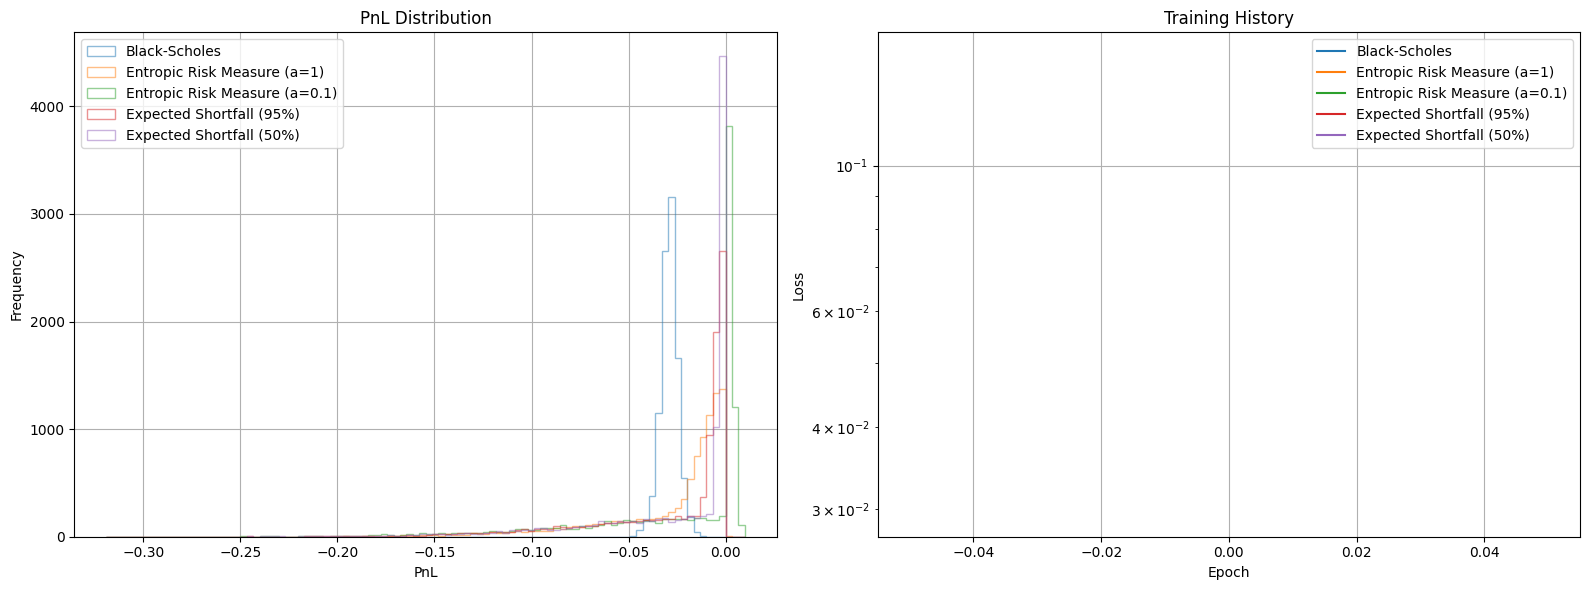

Loss=0.0533: 100%|██████████| 10/10 [00:00<00:00, 13.18it/s]


PnL Statistics:
Black-Scholes: -0.028978 (0.004580)
Entropic Risk Measure (a=1): -0.029872 (0.049089)
Entropic Risk Measure (a=0.1): -0.028598 (0.053330)
Expected Shortfall (95%): -0.029259 (0.039015)
Expected Shortfall (50%): -0.029463 (0.036989)


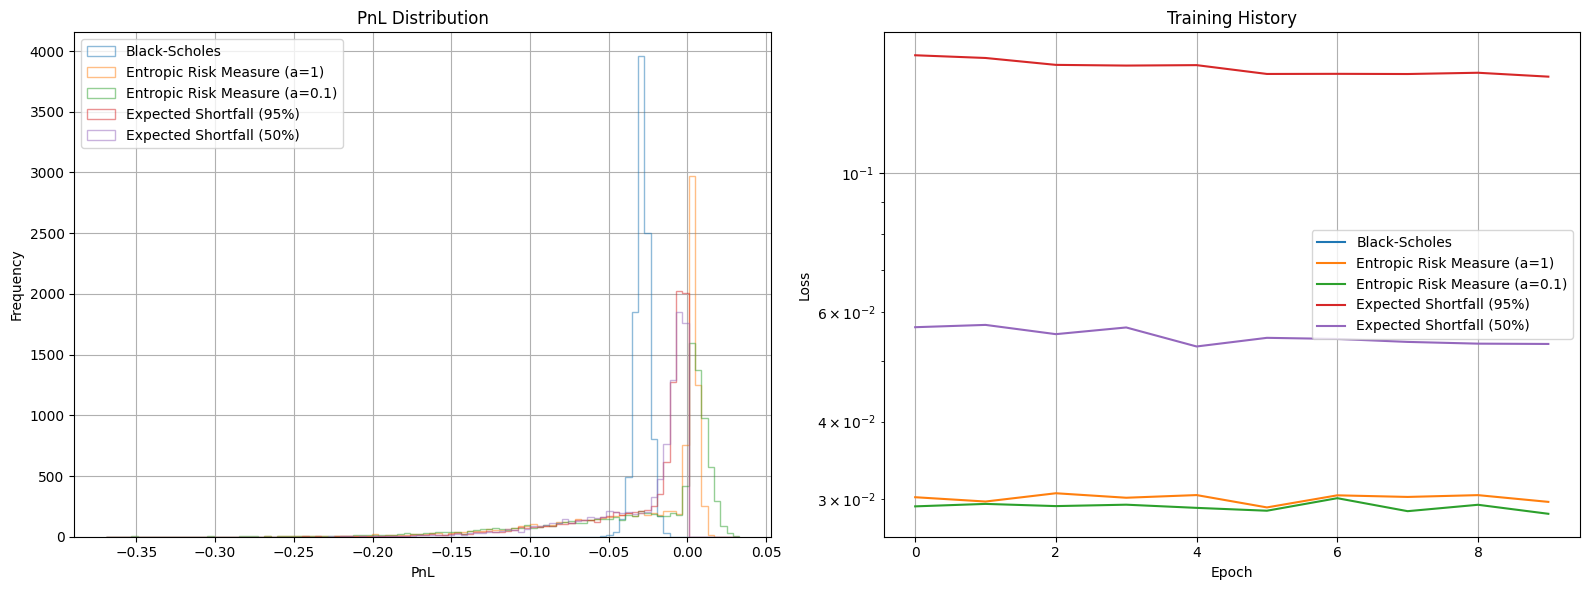

Loss=0.0452: 100%|██████████| 100/100 [00:07<00:00, 13.60it/s]


PnL Statistics:
Black-Scholes: -0.029029 (0.004526)
Entropic Risk Measure (a=1): -0.028741 (0.023301)
Entropic Risk Measure (a=0.1): -0.028732 (0.038236)
Expected Shortfall (95%): -0.028852 (0.020863)
Expected Shortfall (50%): -0.028728 (0.020107)


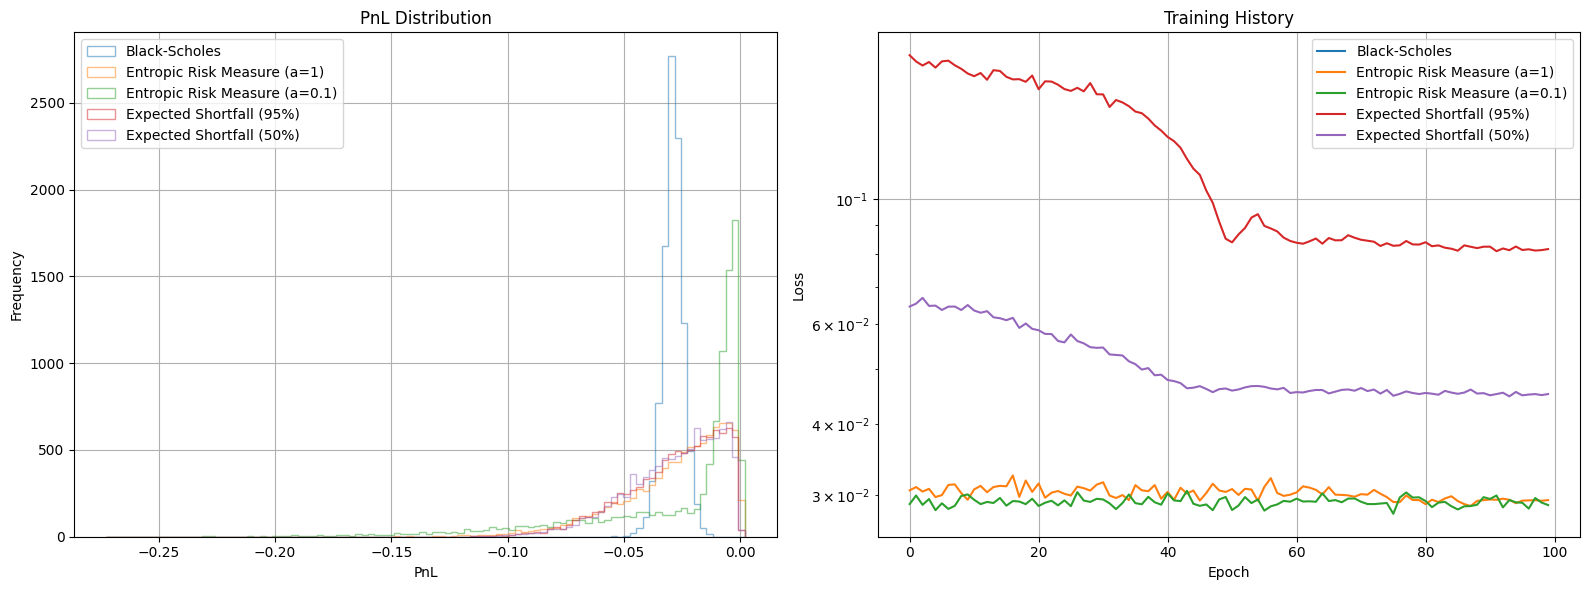

In [17]:
hedgers1 = fit(1, 1, 0, 1, 10000)
hedgers10 = fit(1, 1, 0, 10, 10000)
hedgers100 = fit(1, 1, 0, 100, 10000)

In [18]:
fixed_paths = fixed_stock.max_n_paths(maturity)
fixed_stock1 = FixedStock(spots=list(series), cost=0, dt=dt)
derivative1 = EuropeanOption(fixed_stock1, strike=1, maturity=maturity)
fixed_stock10 = FixedStock(spots=list(series), cost=0, dt=dt)
derivative10 = EuropeanOption(fixed_stock10, strike=10, maturity=maturity)
fixed_stock100 = FixedStock(spots=list(series), cost=0, dt=dt)
derivative100 = EuropeanOption(fixed_stock100, strike=100, maturity=maturity)

losses = []
for iter, hedgers in zip(['1', '10', '100'], [hedgers1, hedgers10, hedgers100]):
    for name_model, (hedger_model, _, _) in hedgers.items():
        if name_model == "Black-Scholes":
            continue
        for name_loss, (hedger_loss, _, _) in hedgers.items():
            if name_loss == "Black-Scholes":
                continue
            hedger = Hedger(hedger_model.model, features, hedger_loss.criterion)
            loss = hedger.compute_loss(derivative1, n_paths=fixed_paths, init_state=(1,), enable_grad=False)
            losses.append((iter, name_model, name_loss, loss.item()))
losses = pd.DataFrame(losses, columns=["epoch", "model", "loss", "value"])
losses.sort_values(['loss', 'model', 'epoch'])

,epoch,model,loss,value
5,1,Entropic Risk Measure (a=0.1),Entropic Risk Measure (a=0.1),0.029435
21,10,Entropic Risk Measure (a=0.1),Entropic Risk Measure (a=0.1),0.030012
37,100,Entropic Risk Measure (a=0.1),Entropic Risk Measure (a=0.1),0.028644
1,1,Entropic Risk Measure (a=1),Entropic Risk Measure (a=0.1),0.028310
17,10,Entropic Risk Measure (a=1),Entropic Risk Measure (a=0.1),0.029573
33,100,Entropic Risk Measure (a=1),Entropic Risk Measure (a=0.1),0.025516
13,1,Expected Shortfall (50%),Entropic Risk Measure (a=0.1),0.028996
29,10,Expected Shortfall (50%),Entropic Risk Measure (a=0.1),0.028505
45,100,Expected Shortfall (50%),Entropic Risk Measure (a=0.1),0.026231
9,1,Expected Shortfall (95%),Entropic Risk Measure (a=0.1),0.028787


Loss=5.8792: 100%|██████████| 1/1 [00:00<00:00, 13.59it/s]


PnL Statistics:
Black-Scholes: -2.911152 (0.459614)
Entropic Risk Measure (a=1): -2.911779 (3.496805)
Entropic Risk Measure (a=0.1): -2.883701 (4.672415)
Expected Shortfall (95%): -2.923620 (4.022446)
Expected Shortfall (50%): -2.894206 (4.242691)


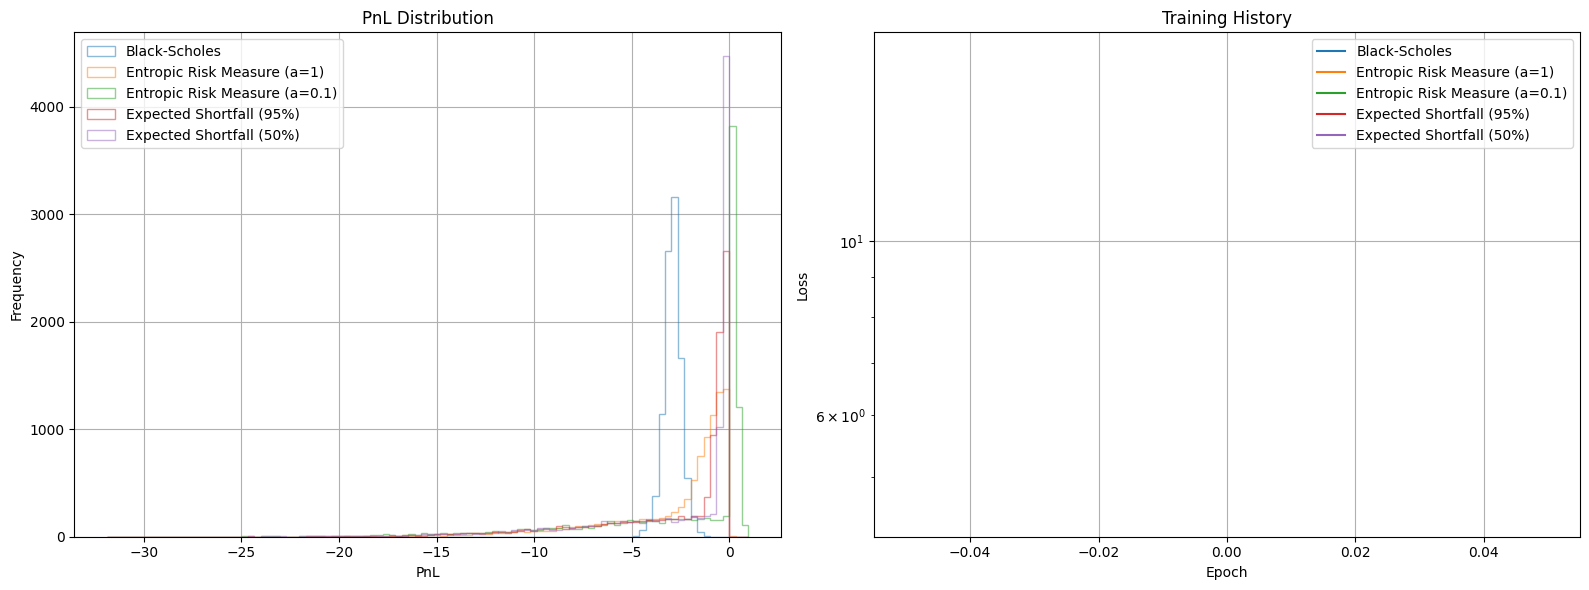

Loss=5.3276: 100%|██████████| 10/10 [00:00<00:00, 13.03it/s]


PnL Statistics:
Black-Scholes: -2.897785 (0.458037)
Entropic Risk Measure (a=1): -2.987060 (4.898764)
Entropic Risk Measure (a=0.1): -2.860283 (5.209055)
Expected Shortfall (95%): -2.925863 (3.901366)
Expected Shortfall (50%): -2.946327 (3.700762)


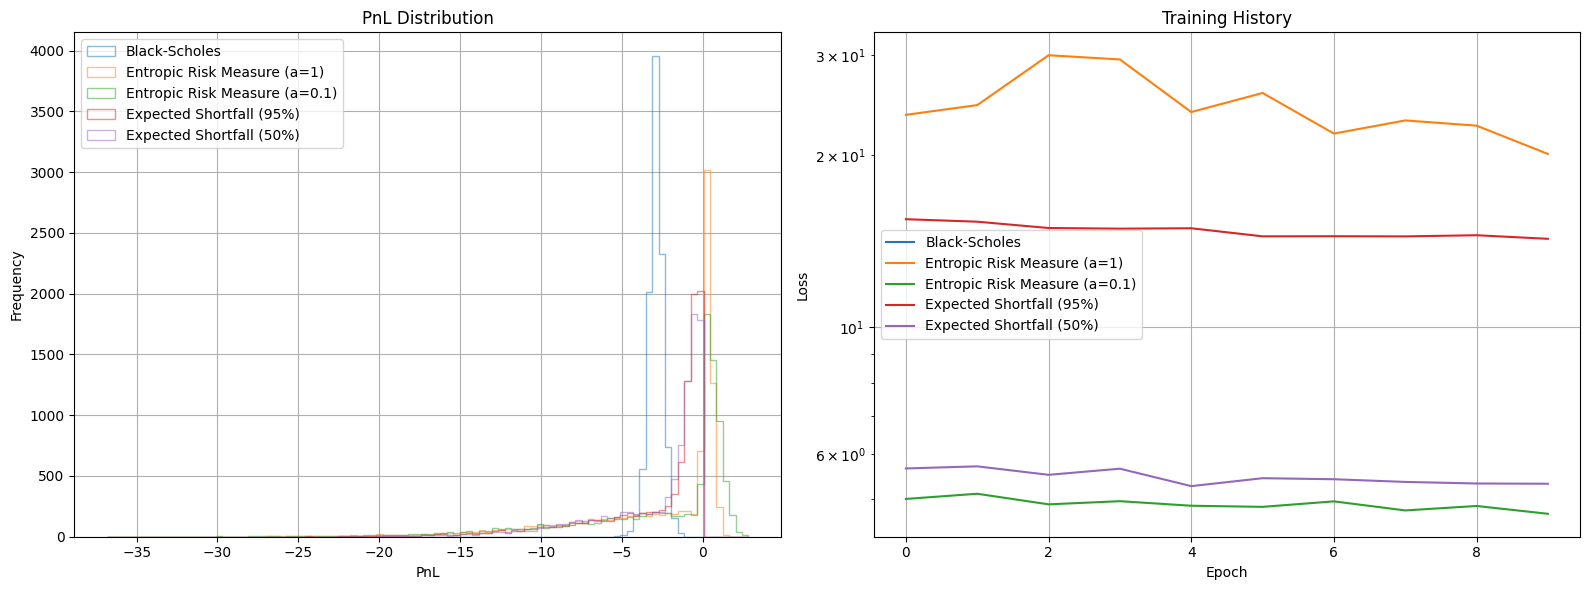

Loss=4.5217: 100%|██████████| 100/100 [00:07<00:00, 13.83it/s]


PnL Statistics:
Black-Scholes: -2.902864 (0.452644)
Entropic Risk Measure (a=1): -2.886651 (2.165014)
Entropic Risk Measure (a=0.1): -2.891203 (2.123279)
Expected Shortfall (95%): -2.885228 (2.086845)
Expected Shortfall (50%): -2.872791 (2.011578)


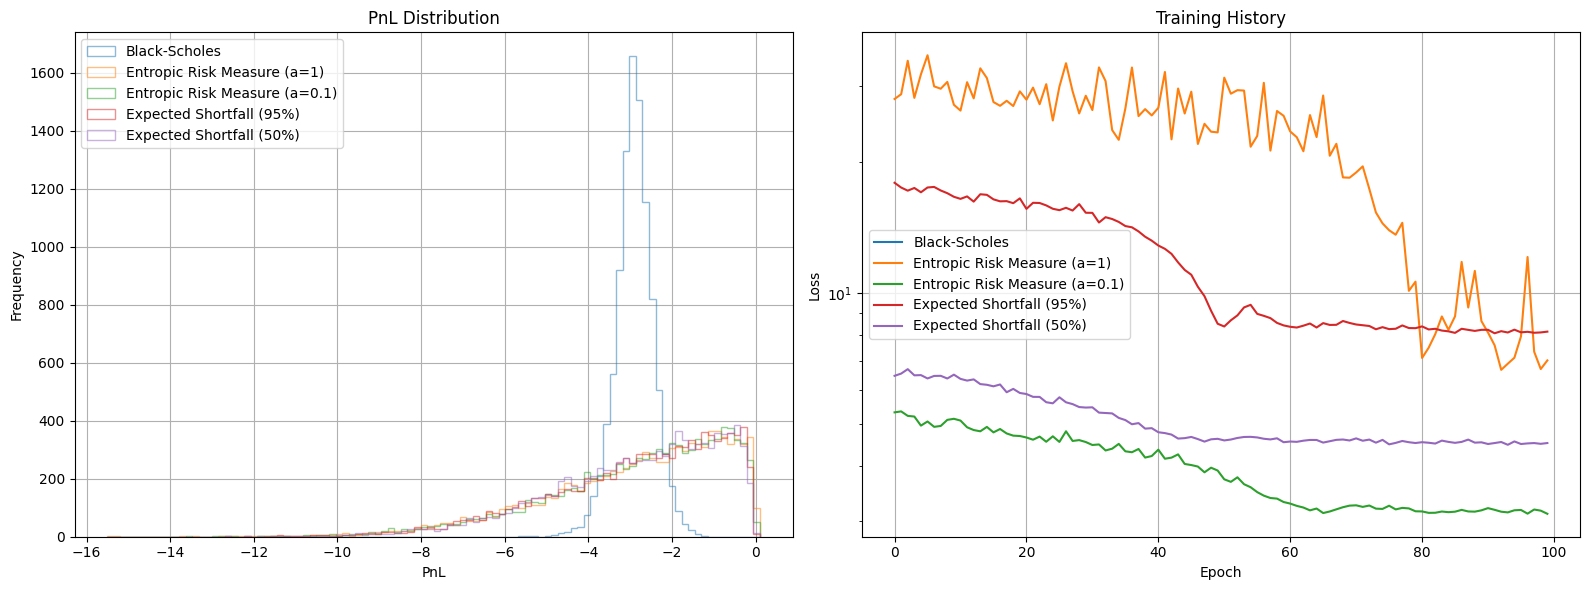

In [19]:
torch.manual_seed(1234)
hedgers1 = fit(100, 100, 0, 1, 10000)
hedgers10 = fit(100, 100, 0, 10, 10000)
hedgers100 = fit(100, 100, 0, 100, 10000)

In [20]:
fixed_paths = fixed_stock.max_n_paths(maturity)
fixed_stock1 = FixedStock(spots=list(series), cost=0, dt=dt)
derivative1 = EuropeanOption(fixed_stock1, strike=1, maturity=maturity)
fixed_stock10 = FixedStock(spots=list(series), cost=0, dt=dt)
derivative10 = EuropeanOption(fixed_stock10, strike=10, maturity=maturity)
fixed_stock100 = FixedStock(spots=list(series), cost=0, dt=dt)
derivative100 = EuropeanOption(fixed_stock100, strike=100, maturity=maturity)

losses = []
for iter, hedgers in zip(['1', '10', '100'], [hedgers1, hedgers10, hedgers100]):
    for name_model, (hedger_model, _, _) in hedgers.items():
        if name_model == "Black-Scholes":
            continue
        for name_loss, (hedger_loss, _, _) in hedgers.items():
            if name_loss == "Black-Scholes":
                continue
            hedger = Hedger(hedger_model.model, features, hedger_loss.criterion)
            loss = hedger.compute_loss(derivative100, n_paths=fixed_paths, init_state=(100,), enable_grad=False)
            losses.append((iter, name_model, name_loss, loss.item()))
losses = pd.DataFrame(losses, columns=["epoch", "model", "loss", "value"])
losses.sort_values(['loss', 'model', 'epoch'])

,epoch,model,loss,value
5,1,Entropic Risk Measure (a=0.1),Entropic Risk Measure (a=0.1),6.722870
21,10,Entropic Risk Measure (a=0.1),Entropic Risk Measure (a=0.1),7.741427
37,100,Entropic Risk Measure (a=0.1),Entropic Risk Measure (a=0.1),3.005104
1,1,Entropic Risk Measure (a=1),Entropic Risk Measure (a=0.1),4.839206
17,10,Entropic Risk Measure (a=1),Entropic Risk Measure (a=0.1),6.978865
33,100,Entropic Risk Measure (a=1),Entropic Risk Measure (a=0.1),3.018837
13,1,Expected Shortfall (50%),Entropic Risk Measure (a=0.1),5.890446
29,10,Expected Shortfall (50%),Entropic Risk Measure (a=0.1),5.113773
45,100,Expected Shortfall (50%),Entropic Risk Measure (a=0.1),2.991014
9,1,Expected Shortfall (95%),Entropic Risk Measure (a=0.1),5.535231
